## objectives
- load a model from the best_models saved
- load the data with options for the same augmentations - one can try predictions with and without different augmentations
- run predictions on the test set and compute overall metrics
- plot a confusion matrix as a heatmap
- list classwise metrics
- vishualize the augmentations, but unnormalized for better understanding
- vishualize a few random predictions from either train or test sets
- vishualize random predictions from a particular class


In [2]:
import timm
import torch
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from tqdm import tqdm

In [3]:
from utils.data import PlantData

data_dir = '/home/takayuki/Desktop/summer2025/plants/data/AquaticPlantLabData/squared'

train_percent = 0.6
val_percent = 0.2
test_percent = 0.2

batch_size = 2

random_seed = 8

torch.manual_seed(random_seed)
np.random.seed(random_seed)


data = PlantData(data_dir, batch_size, train_percent, val_percent, test_percent, random_seed)
# data.calc_split_sizes()    

train_dataloader, val_dataloader, test_dataloader = data.get_dataloaders()
data.get_split_info()                    

+--------------------------+---------------+--------------------+--------------+
| Class Name               |   Train Count |   Validation Count |   Test Count |
+==========================+===============+====================+==============+
| Brasenia schreberi       |             5 |                  2 |            2 |
+--------------------------+---------------+--------------------+--------------+
| Cabomba                  |             3 |                  1 |            1 |
+--------------------------+---------------+--------------------+--------------+
| Ceratophyllum demersum   |            13 |                  4 |            4 |
+--------------------------+---------------+--------------------+--------------+
| Elodea canadensis        |             9 |                  3 |            3 |
+--------------------------+---------------+--------------------+--------------+
| Heteranthera dubia       |             4 |                  2 |            1 |
+--------------------------+

In [4]:
timm.list_models('*convnextv2*', pretrained=True)

['convnextv2_atto.fcmae',
 'convnextv2_atto.fcmae_ft_in1k',
 'convnextv2_base.fcmae',
 'convnextv2_base.fcmae_ft_in1k',
 'convnextv2_base.fcmae_ft_in22k_in1k',
 'convnextv2_base.fcmae_ft_in22k_in1k_384',
 'convnextv2_femto.fcmae',
 'convnextv2_femto.fcmae_ft_in1k',
 'convnextv2_huge.fcmae',
 'convnextv2_huge.fcmae_ft_in1k',
 'convnextv2_huge.fcmae_ft_in22k_in1k_384',
 'convnextv2_huge.fcmae_ft_in22k_in1k_512',
 'convnextv2_large.fcmae',
 'convnextv2_large.fcmae_ft_in1k',
 'convnextv2_large.fcmae_ft_in22k_in1k',
 'convnextv2_large.fcmae_ft_in22k_in1k_384',
 'convnextv2_nano.fcmae',
 'convnextv2_nano.fcmae_ft_in1k',
 'convnextv2_nano.fcmae_ft_in22k_in1k',
 'convnextv2_nano.fcmae_ft_in22k_in1k_384',
 'convnextv2_pico.fcmae',
 'convnextv2_pico.fcmae_ft_in1k',
 'convnextv2_tiny.fcmae',
 'convnextv2_tiny.fcmae_ft_in1k',
 'convnextv2_tiny.fcmae_ft_in22k_in1k',
 'convnextv2_tiny.fcmae_ft_in22k_in1k_384']

In [5]:
timm_model_name = "convnextv2_tiny.fcmae_ft_in22k_in1k"

best_model_path = "/home/takayuki/Desktop/summer2025/plants/training/models/best_model_06-21_12-52--22_tiny28M_stratified_convnextv2_tiny.fcmae_ft_in22k_in1k.pth"
if not os.path.exists(best_model_path):
    raise FileNotFoundError(f"Model file not found: {best_model_path}")

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cuda':
    torch.cuda.manual_seed(random_seed)
    print("GPU: ", torch.cuda.get_device_name(0))
    
model = timm.create_model(timm_model_name, pretrained=False, num_classes=21)
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)
model.eval()

print(f"Model loaded from {best_model_path}")


Using device: cpu
Model loaded from /home/takayuki/Desktop/summer2025/plants/training/models/best_model_06-21_12-52--22_tiny28M_stratified_convnextv2_tiny.fcmae_ft_in22k_in1k.pth


In [7]:
import torch
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import os

def evaluate_model_on_test_set(model_to_evaluate, dataloader, current_device, class_names_list):
    print("\nStarting evaluation on the test set...")
    model_to_evaluate.eval()  

    all_predictions = []
    all_true_labels = []

    with torch.no_grad():
        for batch_idx, (images, labels) in tqdm(enumerate(dataloader), total=len(dataloader), desc="Evaluating", unit="batch"):
            images = images.to(current_device)
            labels = labels.to(current_device)

            outputs = model_to_evaluate(images)
            _, predicted_classes = torch.max(outputs, 1) 

            all_predictions.extend(predicted_classes.cpu().numpy())
            all_true_labels.extend(labels.cpu().numpy())


    print("\n--- Test Set Evaluation Results ---")

    accuracy = accuracy_score(all_true_labels, all_predictions)
    print(f"Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

    print("\nClassification Report:")
    report_labels_indices = list(range(len(class_names_list)))
    print(classification_report(all_true_labels, all_predictions,
                                labels=report_labels_indices,
                                target_names=class_names_list,
                                zero_division=0)) 
    
    return accuracy, all_true_labels, all_predictions

In [8]:
import torch
from tqdm import tqdm
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
from tabulate import tabulate
import numpy as np 

def evaluate_model_on_test_set(model_to_evaluate, dataloader, current_device, class_names_list):
    model_to_evaluate.eval()
    all_predictions = []
    all_true_labels = []
    num_classes = len(class_names_list)

    with torch.no_grad():
        for batch_idx, (images_batch, labels_batch) in tqdm(enumerate(dataloader), total=len(dataloader), desc="Evaluating", unit="batch"):
            images = images_batch.to(current_device)
            labels = labels_batch.to(current_device)

            if images.dim() != 4:
                if images.dim() == 3 and images.shape[0] == 3 and dataloader.batch_size == 1:
                    images = images.unsqueeze(0)
                else:
                    print(f"Skipping batch {batch_idx} due to unexpected image dimensions: {images.shape}")
                    continue
            try:
                outputs = model_to_evaluate(images)
            except RuntimeError as e:
                print(f"RuntimeError on batch {batch_idx} (shape: {images.shape}): {e}. Skipping.")
                continue

            _, predicted_classes = torch.max(outputs, 1)
            all_predictions.extend(predicted_classes.cpu().numpy())
            all_true_labels.extend(labels.cpu().numpy())

    if not all_true_labels or not all_predictions:
        print("ERROR: No data collected for evaluation.")
        return 0.0, [], []

    accuracy = accuracy_score(all_true_labels, all_predictions)
    print(f"\nOverall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

    cm = confusion_matrix(all_true_labels, all_predictions, labels=list(range(num_classes)))
    
    metrics_data = []
    headers = ["Class", "Precision", "Recall (TPR)", "F1-Score", "Specificity (TNR)", "FPR", "TP", "FP", "FN", "Support"]
    
    class_precisions = []
    class_recalls = []
    class_f1s = []
    class_specificities = []
    class_fprs = []
    class_supports = []

    for i, class_name in enumerate(class_names_list):
        TP = cm[i, i]
        FP = cm[:, i].sum() - TP
        FN = cm[i, :].sum() - TP
        TN = cm.sum() - (TP + FP + FN)
        support = TP + FN

        precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        recall_tpr = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        f1 = 2 * (precision * recall_tpr) / (precision + recall_tpr) if (precision + recall_tpr) > 0 else 0.0
        specificity_tnr = TN / (TN + FP) if (TN + FP) > 0 else 0.0
        fpr = FP / (FP + TN) if (FP + TN) > 0 else 0.0
        
        metrics_data.append([
            class_name, f"{precision:.4f}", f"{recall_tpr:.4f}", f"{f1:.4f}",
            f"{specificity_tnr:.4f}", f"{fpr:.4f}", TP, FP, FN, support
        ])
        
        class_precisions.append(precision)
        class_recalls.append(recall_tpr)
        class_f1s.append(f1)
        class_specificities.append(specificity_tnr)
        class_fprs.append(fpr)
        class_supports.append(support)
    
    print("\nPer-Class Metrics:")
    print(tabulate(metrics_data, headers=headers, tablefmt="grid"))
    
    macro_precision = np.mean(class_precisions)
    macro_recall = np.mean(class_recalls)
    macro_f1 = np.mean(class_f1s)
    macro_specificity = np.mean(class_specificities) 
    macro_fpr = np.mean(class_fprs) 

    
    if sum(class_supports) > 0:
        weighted_precision = np.average(class_precisions, weights=class_supports)
        weighted_recall = np.average(class_recalls, weights=class_supports)
        weighted_f1 = np.average(class_f1s, weights=class_supports)
        weighted_specificity = np.average(class_specificities, weights=class_supports) 
        weighted_fpr = np.average(class_fprs, weights=class_supports) 
        
        weighted_precision = weighted_recall = weighted_f1 = weighted_specificity = weighted_fpr = 0.0

    summary_data = [
        ["Macro Avg", f"{macro_precision:.4f}", f"{macro_recall:.4f}", f"{macro_f1:.4f}", f"{macro_specificity:.4f}", f"{macro_fpr:.4f}", "-", "-", "-", sum(class_supports)],
        ["Weighted Avg", f"{weighted_precision:.4f}", f"{weighted_recall:.4f}", f"{weighted_f1:.4f}", f"{weighted_specificity:.4f}", f"{weighted_fpr:.4f}", "-", "-", "-", sum(class_supports)]
    ]
    print("\nSummary Metrics:")
    print(tabulate(summary_data, headers=headers, tablefmt="grid"))
        
    return accuracy, all_true_labels, all_predictions

#### Some evaluation metrics and what they mean:

- Accuracy: correct predictions / total predictions

- False Positive Rate: FP / (TN + FP): Tells how many of the actual negatives we predicted as positives.

- Sensitivity (True Positive Rate): TP / (TP + FN): Tells how many of the actual positives we predicted correctly.

- Specificity (True Negative Rate): TN / (TN + FP): Tells how many of the actual negatives we predicted correctly.

- Precision: TP / (TP + FP): Tells how many of the ones we predicted as positive are actually positive.

- Recall: TP / (TP + FN): Tells how many of the actual positives we predicted correctly.

- F1 Score: Harmonic mean of precision and recall

In [9]:
test_accuracy, true_labels, predictions = evaluate_model_on_test_set(model, test_dataloader, device, data.dataset_init.classes)

Evaluating: 100%|██████████| 23/23 [00:07<00:00,  2.93batch/s]


Overall Accuracy: 0.8000 (80.00%)

Per-Class Metrics:
+--------------------------+-------------+----------------+------------+---------------------+--------+------+------+------+-----------+
| Class                    |   Precision |   Recall (TPR) |   F1-Score |   Specificity (TNR) |    FPR |   TP |   FP |   FN |   Support |
+==========================+=============+================+============+=====================+========+======+======+======+===========+
| Brasenia schreberi       |      1      |           1    |     1      |              1      | 0      |    2 |    0 |    0 |         2 |
+--------------------------+-------------+----------------+------------+---------------------+--------+------+------+------+-----------+
| Cabomba                  |      1      |           1    |     1      |              1      | 0      |    1 |    0 |    0 |         1 |
+--------------------------+-------------+----------------+------------+---------------------+--------+------+------+------

## Invasive and Non-Invasive Species Classification

Invasive species 'Cabomba' found at index 1
Invasive species 'Hydrocharis morsus-ranae' found at index 5
Invasive species 'Myriophyllum spicatum' found at index 7
Invasive species 'Nitellopsis obtusa' found at index 9
Invasive species 'Potamogeton crispus' found at index 12

Multi-Class Confusion Matrix (Invasive species highlighted):


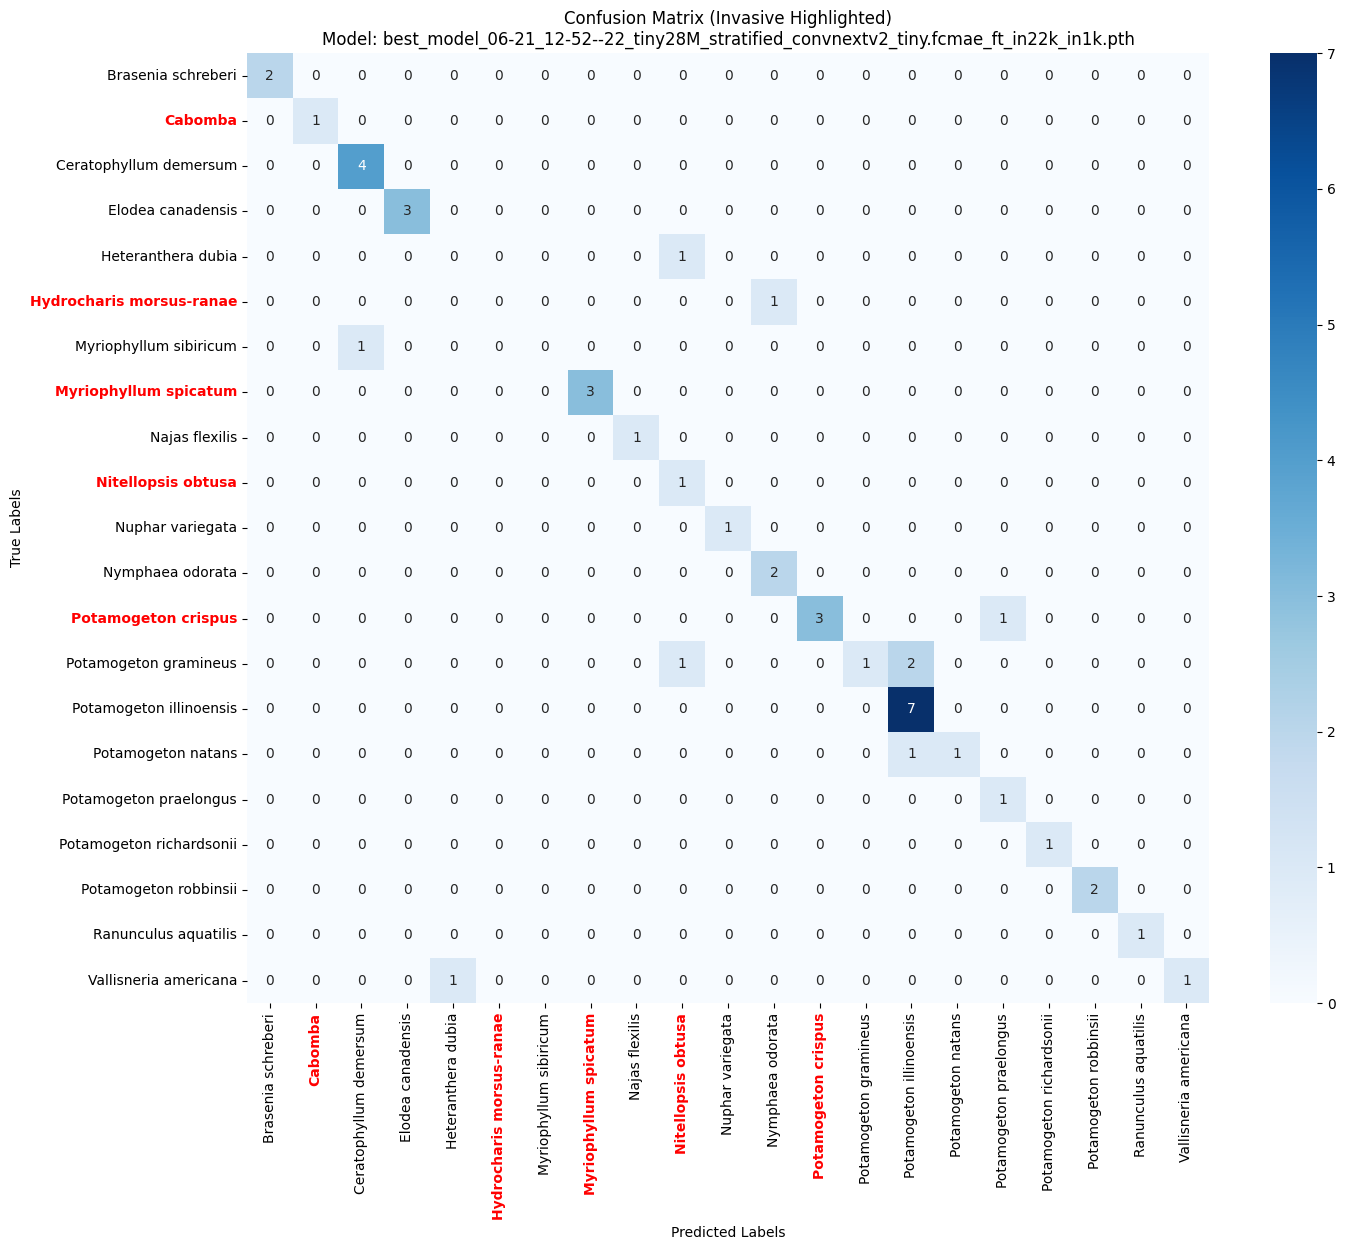

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

invasive_species_names = [ 
    "Hydrocharis morsus-ranae",
    "Myriophyllum spicatum",
    "Nitellopsis obtusa",
    "Potamogeton crispus",
    "Cabomba" 
]
invasive_indices = []

for i, class_name in enumerate(data.dataset_init.classes):
    if class_name in invasive_species_names:
        invasive_indices.append(i)
        print(f"Invasive species '{class_name}' found at index {i}")


print("\nMulti-Class Confusion Matrix (Invasive species highlighted):")
all_class_names = data.dataset_init.classes 
num_all_classes = len(all_class_names)

cm_all_classes = confusion_matrix(true_labels, predictions, labels=list(range(num_all_classes)))

plt.figure(figsize=(max(10, num_all_classes * 0.7), max(8, num_all_classes * 0.6))) 
ax = sns.heatmap(cm_all_classes, annot=True, fmt='d', cmap='Blues',
                 xticklabels=all_class_names, yticklabels=all_class_names)

invasive_color = 'red'
non_invasive_color = 'black' 

for ticklabel in ax.get_xticklabels():
    if ticklabel.get_text() in invasive_species_names:
        ticklabel.set_color(invasive_color)
        ticklabel.set_weight('bold') 
    else:
        ticklabel.set_color(non_invasive_color)

for ticklabel in ax.get_yticklabels():
    if ticklabel.get_text() in invasive_species_names:
        ticklabel.set_color(invasive_color)
        ticklabel.set_weight('bold') 
    else:
        ticklabel.set_color(non_invasive_color)

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title(f"Confusion Matrix (Invasive Highlighted)\nModel: {os.path.basename(best_model_path)}")
plt.tight_layout()
plt.show() 


Invasive vs. Non-Invasive Confusion Matrix:


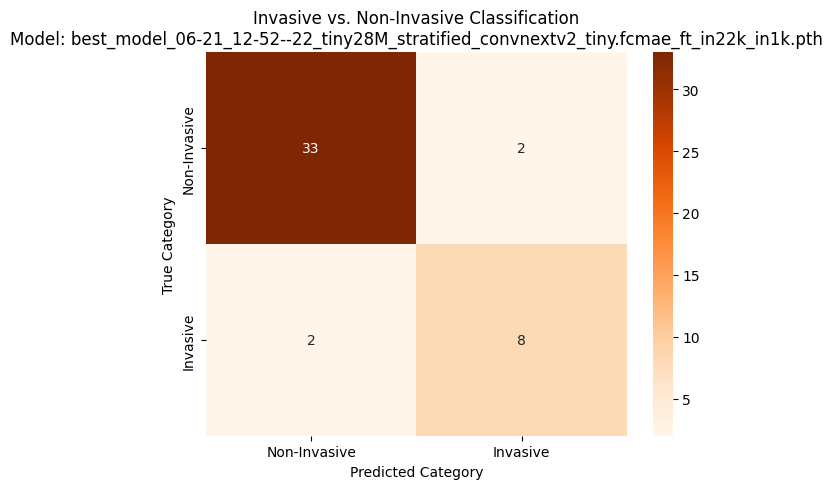

In [11]:
true_labels_np = np.array(true_labels)
predictions_np = np.array(predictions)

true_binary = np.isin(true_labels_np, invasive_indices).astype(int)
pred_binary = np.isin(predictions_np, invasive_indices).astype(int)

# Confusion matrix
binary_class_names = ["Non-Invasive", "Invasive"]

cm_binary = confusion_matrix(true_binary, pred_binary, labels=[0, 1]) 

print("\nInvasive vs. Non-Invasive Confusion Matrix:")

plt.figure(figsize=(6, 5))
sns.heatmap(cm_binary, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=binary_class_names, yticklabels=binary_class_names)
plt.xlabel("Predicted Category")
plt.ylabel("True Category")
plt.title(f"Invasive vs. Non-Invasive Classification\nModel: {os.path.basename(best_model_path)}")
plt.tight_layout()
plt.show()


In [12]:
# Positive = Invasive, Negative = Non-Invasive

TN = cm_binary[0, 0] # True Non-Invasive predicted as Non-Invasive
FP = cm_binary[0, 1] # True Non-Invasive predicted as Invasive
FN = cm_binary[1, 0] # True Invasive predicted as Non-Invasive
TP = cm_binary[1, 1] # True Invasive predicted as Invasive

fpr = FP / (FP + TN) # False Positive Rate - proportion of Non-Invasive species incorrectly classified as Invasive
fnr = FN / (TP + FN) # False Negative Rate - proportion of Invasive species incorrectly classified as Non-Invasive {this is important!}
tnr = TN / (TN + FP) # True Negative Rate (Specificity) - proportion of Non-Invasive species correctly classified
tpr = TP / (TP + FN) # True Positive Rate (Recall or Sensitivity) - proportion of Invasive species correctly classified

ppv = TP / (TP + FP) # Positive Predictive Value (Precision) - proportion of predicted Invasive species that are actually Invasive
npv = TN / (TN + FN) # Negative Predictive Value - proportion of Non-Invasive predictions that are actually Non-Invasive

f1 = 2 * (ppv * tpr) / (ppv + tpr) # F1-Score (Harmonic mean of Precision and Recall) - how well the model balances precision and recall 
overall_accuracy = (TN + TP) / cm_binary.sum() # Overall correct classification rate

metrics_data = [
    ["True Positives (TP)", TP],
    ["True Negatives (TN)", TN],
    ["False Positives (FP)", FP],
    ["False Negatives (FN)", FN],
    ["False Positive Rate (FPR)", f"{fpr:.4f}"],
    ["False Negative Rate (FNR)", f"{fnr:.4f}"],
    ["(TNR or Specificity)", f"{tnr:.4f}"],
    ["(TPR or Sensitivity or Recall)", f"{tpr:.4f}"],
    ["Negative Predictive Value (NPV)", f"{npv:.4f}"],
    ["Positive \" (PPV or Precision)", f"{ppv:.4f}"],
    ["F1 Score", f"{f1:.4f}"],
    ["Overall Accuracy", f"{overall_accuracy:.4f}"]
]

headers = ["Confusion Matrix", "Values", "Rates", "Metrics", "Predictive Values & Overall", "Metrics"]
metrics_col_wise = []
num_metrics = len(metrics_data)
rows_per_col = (num_metrics + 2) // 3 
for r in range(rows_per_col):
    new_row = []
    for c in range(3): 
        metric_index = r + c * rows_per_col
        if metric_index < num_metrics:
            new_row.extend(metrics_data[metric_index])
        else:
            new_row.extend(["", ""]) 
    metrics_col_wise.append(new_row)


print("\nBinary Classification Metrics:")
print("Positive = Invasive & Negative = Non-Invasive")
print(tabulate(metrics_col_wise, headers=headers, tablefmt="grid"))


Binary Classification Metrics:
Positive = Invasive & Negative = Non-Invasive
+----------------------+----------+--------------------------------+-----------+---------------------------------+-----------+
| Confusion Matrix     |   Values | Rates                          |   Metrics | Predictive Values & Overall     |   Metrics |
+======================+==========+================================+===========+=================================+===========+
| True Positives (TP)  |        8 | False Positive Rate (FPR)      |    0.0571 | Negative Predictive Value (NPV) |    0.9429 |
+----------------------+----------+--------------------------------+-----------+---------------------------------+-----------+
| True Negatives (TN)  |       33 | False Negative Rate (FNR)      |    0.2    | Positive " (PPV or Precision)   |    0.8    |
+----------------------+----------+--------------------------------+-----------+---------------------------------+-----------+
| False Positives (FP) |        2